# Sales Performance Analysis — Alfido Tech
### Regions, Categories, Time, Top/Worst Products & Seasonality

**Dataset:** Superstore Sales (Kaggle — `bhanupratapbiswas/superstore-sales`)
**File used:** `superstore_final_dataset.csv` (9,800 order lines, 4,922 orders, 793 customers, 1,861 products)
**Time period:** January 2015 – December 2018
**Author:** Alfido Tech Data Analytics Internship

**Goal:** Analyze sales performance across regions, categories, and time; identify best/worst performing products and seasonality; recommend tactical improvements.

> **Scope note:** this extract of the Superstore dataset includes `Sales` but does **not** include `Quantity`, `Discount`, or `Profit` columns (present in some other Superstore extracts). This means **profit margin and conversion-rate KPIs cannot be computed** from this file. The analysis below focuses on the KPIs the data actually supports: Revenue, Average Order Value, and revenue-based rankings of products/regions/categories.

---
## Contents
1. Load & Inspect Data
2. Data Cleaning
3. KPIs
4. Regional & Category Performance
5. Seasonality & Trends
6. Best & Worst Performing Products
7. Key Findings
8. Tactical Recommendations for Alfido Tech


## 1. Load & Inspect Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = ["#2E5077", "#4DA1A9", "#F6A05C", "#C6493D", "#79A44D", "#8E6C9E", "#D4A5A5", "#5B8C5A"]

df = pd.read_csv("superstore_final_dataset.csv", encoding="latin1")
print(df.shape)
df.head()


(9800, 18)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   str    
 2   Order_Date     9800 non-null   str    
 3   Ship_Date      9800 non-null   str    
 4   Ship_Mode      9800 non-null   str    
 5   Customer_ID    9800 non-null   str    
 6   Customer_Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product_ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub_Category   9800 non-null   str    
 16  Product_Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row_ID,9800.0,NaN,NaN,NaN,4900.5,2829.160653,1.0,2450.75,4900.5,7350.25,9800.0
Order_ID,9800,4922,CA-2018-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,9800,1230,5/9/2017,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship_Date,9800,1326,26/09/2018,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship_Mode,9800,4,Standard Class,5859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,9800,793,WB-21850,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Name,9800,793,William Brown,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9800,3,Consumer,5101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9800,1,United States,9800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9800,529,New York City,891,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.isna().sum()


Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

**Observations from initial inspection:**
- 9,800 order-line rows, 4,922 unique orders, 793 customers, 1,861 unique products
- Columns present: order/ship dates, ship mode, customer, geography, product hierarchy, and `Sales`
- No `Quantity`, `Discount`, or `Profit` columns — profit margin cannot be calculated
- `Order_Date` / `Ship_Date` are stored as text in **day-first** format (DD/MM/YYYY) — confirmed by checking for day values > 12
- 11 rows have a missing `Postal_Code` (not used in this analysis)
- No duplicate rows, no zero/negative `Sales` values


## 2. Data Cleaning

In [5]:
# Parse dates as day-first
df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True)
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], dayfirst=True)

before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

# Shipping duration and time features
df["Ship_Duration_Days"] = (df["Ship_Date"] - df["Order_Date"]).dt.days
df["Order_Year"] = df["Order_Date"].dt.year
df["Order_Month"] = df["Order_Date"].dt.month
df["Order_YearMonth"] = df["Order_Date"].dt.to_period("M").astype(str)
df["Order_Quarter"] = df["Order_Date"].dt.to_period("Q").astype(str)
df["Month_Name"] = df["Order_Date"].dt.month_name()

print(f"Date range: {df['Order_Date'].min().date()} to {df['Order_Date'].max().date()}")


Removed 0 duplicate rows
Date range: 2015-01-03 to 2018-12-30


## 3. KPIs

In [6]:
total_revenue = df["Sales"].sum()
n_orders = df["Order_ID"].nunique()
aov = df.groupby("Order_ID")["Sales"].sum().mean()
n_products = df["Product_ID"].nunique()
n_customers = df["Customer_ID"].nunique()
avg_ship_days = df["Ship_Duration_Days"].mean()

print(f"Total Revenue:        ${total_revenue:,.2f}")
print(f"Unique Orders:        {n_orders:,}")
print(f"Average Order Value:  ${aov:,.2f}")
print(f"Unique Products Sold: {n_products:,}")
print(f"Unique Customers:     {n_customers:,}")
print(f"Avg Shipping Time:    {avg_ship_days:.1f} days")
print()
print("Note: Profit margin and conversion-rate KPIs are not computable — this")
print("dataset does not include Profit, Cost, Quantity, or Discount fields, or")
print("any visit/session data needed for a conversion rate.")


Total Revenue:        $2,261,536.78
Unique Orders:        4,922
Average Order Value:  $459.48
Unique Products Sold: 1,861
Unique Customers:     793
Avg Shipping Time:    4.0 days

Note: Profit margin and conversion-rate KPIs are not computable — this
dataset does not include Profit, Cost, Quantity, or Discount fields, or
any visit/session data needed for a conversion rate.


In [7]:
yearly = df.groupby("Order_Year")["Sales"].sum()
yoy_growth = yearly.pct_change() * 100
pd.DataFrame({"Revenue": yearly, "YoY Growth %": yoy_growth.round(1)})


,Revenue,YoY Growth %
Order_Year,,
2015,479856.2081,NaN
2016,459436.0054,-4.3
2017,600192.5500,30.6
2018,722052.0192,20.3


## 4. Regional & Category Performance

In [8]:
region_profile = df.groupby("Region").agg(
    Revenue=("Sales", "sum"), Orders=("Order_ID", "nunique"), Customers=("Customer_ID", "nunique")
).sort_values("Revenue", ascending=False)
region_profile["AOV"] = region_profile["Revenue"] / region_profile["Orders"]
region_profile["Pct_of_Revenue"] = region_profile["Revenue"] / region_profile["Revenue"].sum() * 100
region_profile.round(2)


,Revenue,Orders,Customers,AOV,Pct_of_Revenue
Region,,,,,
West,710219.68,1587,681,447.52,31.40
East,669518.73,1369,669,489.06,29.60
Central,492646.91,1156,626,426.17,21.78
South,389151.46,810,509,480.43,17.21


In [9]:
category_profile = df.groupby("Category").agg(
    Revenue=("Sales", "sum"), Orders=("Order_ID", "nunique")
).sort_values("Revenue", ascending=False)
category_profile["Pct_of_Revenue"] = category_profile["Revenue"] / category_profile["Revenue"].sum() * 100
category_profile.round(2)


,Revenue,Orders,Pct_of_Revenue
Category,,,
Technology,827455.87,1519,36.59
Furniture,728658.58,1727,32.22
Office Supplies,705422.33,3676,31.19


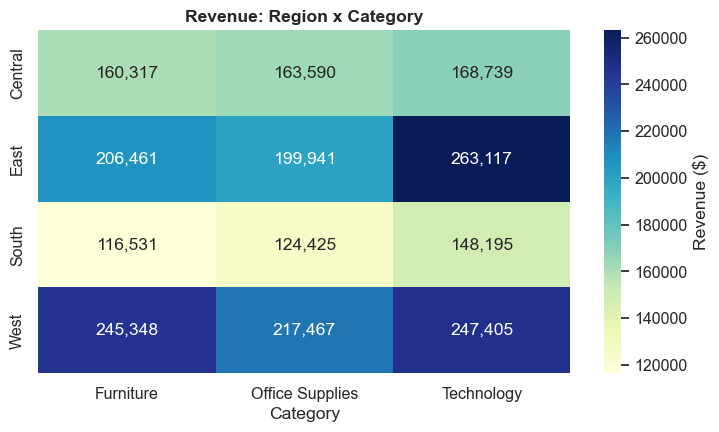

In [10]:
pivot = df.pivot_table(index="Region", columns="Category", values="Sales", aggfunc="sum")
plt.figure(figsize=(7.5, 4.5))
sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="YlGnBu", cbar_kws={"label": "Revenue ($)"})
plt.title("Revenue: Region x Category", fontweight="bold")
plt.ylabel("")
plt.tight_layout()
plt.show()


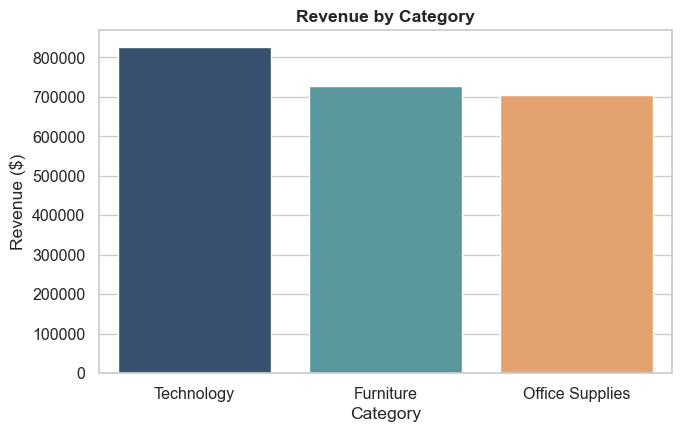

In [11]:
cat_rev = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(7, 4.5))
ax = sns.barplot(x=cat_rev.index, y=cat_rev.values, hue=cat_rev.index, palette=PALETTE[:3], legend=False)
plt.title("Revenue by Category", fontweight="bold")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()


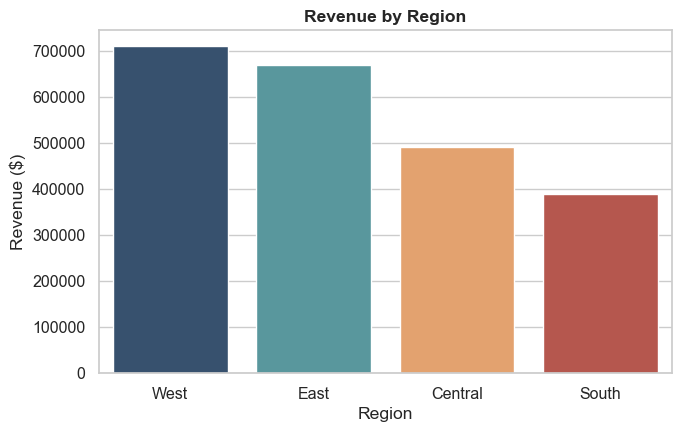

In [12]:
reg_rev = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(7, 4.5))
ax = sns.barplot(x=reg_rev.index, y=reg_rev.values, hue=reg_rev.index, palette=PALETTE[:4], legend=False)
plt.title("Revenue by Region", fontweight="bold")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()


## 5. Seasonality & Trends

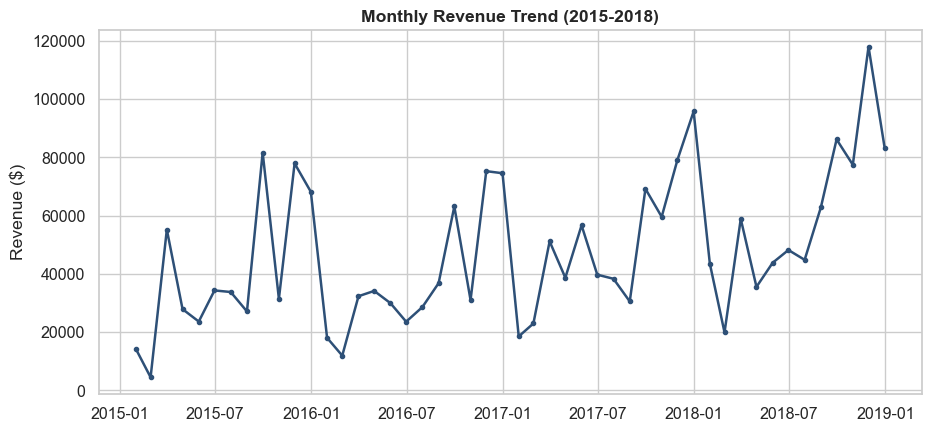

In [13]:
monthly = df.set_index("Order_Date").resample("ME")["Sales"].sum()
plt.figure(figsize=(9.5, 4.5))
plt.plot(monthly.index, monthly.values, color=PALETTE[0], linewidth=1.8, marker="o", markersize=3)
plt.title("Monthly Revenue Trend (2015-2018)", fontweight="bold")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()


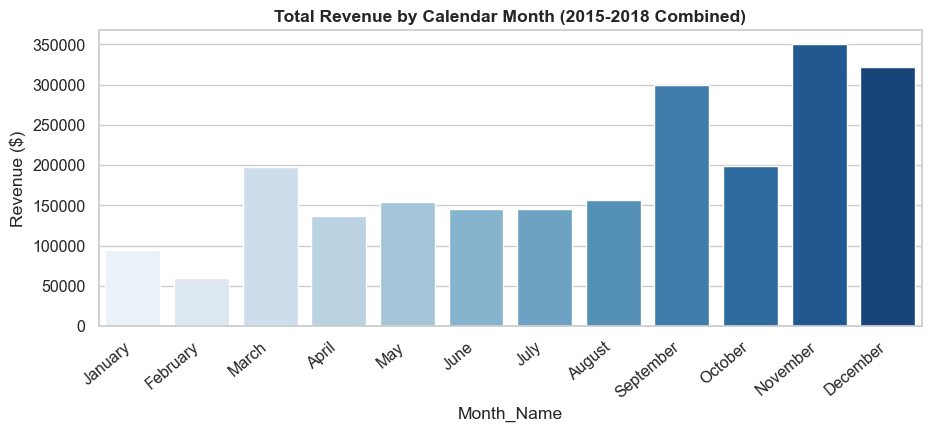

In [14]:
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
seasonal = df.groupby("Month_Name")["Sales"].sum().reindex(month_order)
plt.figure(figsize=(9.5, 4.5))
ax = sns.barplot(x=seasonal.index, y=seasonal.values, hue=seasonal.index, palette=sns.color_palette("Blues", 12), legend=False)
plt.title("Total Revenue by Calendar Month (2015-2018 Combined)", fontweight="bold")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


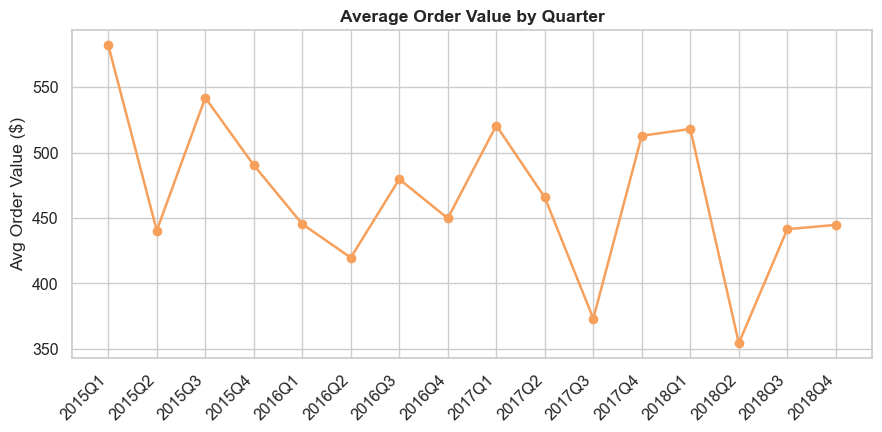

In [15]:
order_level = df.groupby(["Order_ID", "Order_Quarter"])["Sales"].sum().reset_index()
aov_by_q = order_level.groupby("Order_Quarter")["Sales"].mean()
plt.figure(figsize=(9, 4.5))
plt.plot(aov_by_q.index, aov_by_q.values, color=PALETTE[2], linewidth=1.8, marker="o")
plt.title("Average Order Value by Quarter", fontweight="bold")
plt.ylabel("Avg Order Value ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 6. Best & Worst Performing Products

In [16]:
prod_stats = df.groupby("Product_Name").agg(
    Revenue=("Sales", "sum"), Orders=("Order_ID", "nunique")
).sort_values("Revenue", ascending=False)

print("Top 10 products by revenue:")
prod_stats.head(10)


Top 10 products by revenue:


,Revenue,Orders
Product_Name,,
Canon imageCLASS 2200 Advanced Copier,61599.824,5
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,10
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,1
HON 5400 Series Task Chairs for Big and Tall,21870.576,8
GBC DocuBind TL300 Electric Binding System,19823.479,11
GBC Ibimaster 500 Manual ProClick Binding System,19024.500,9
Hewlett Packard LaserJet 3310 Copier,18839.686,8
HP Designjet T520 Inkjet Large Format Printer - 24 Color,18374.895,3
GBC DocuBind P400 Electric Binding System,17965.068,6


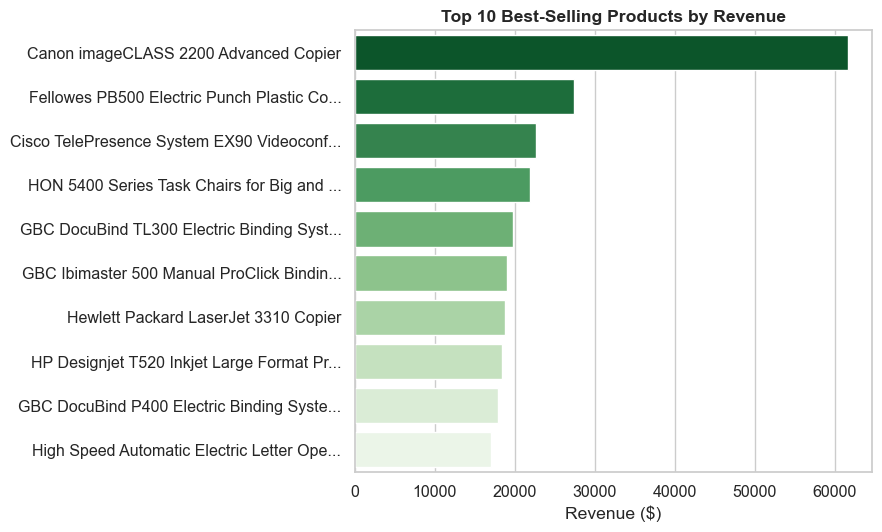

In [17]:
top_products = prod_stats.head(10)
plt.figure(figsize=(9, 5.5))
labels = [p[:40] + ("..." if len(p) > 40 else "") for p in top_products.index]
ax = sns.barplot(x=top_products["Revenue"].values, y=labels, hue=top_products.index, palette=sns.color_palette("Greens_r", 10), legend=False)
plt.title("Top 10 Best-Selling Products by Revenue", fontweight="bold")
plt.xlabel("Revenue ($)")
plt.tight_layout()
plt.show()


In [18]:
# Worst performers: lowest revenue among products with at least 2 orders
# (excludes one-off items where low revenue is just low sample size)
worst_products = prod_stats[prod_stats["Orders"] >= 2].sort_values("Revenue").head(10)
worst_products


,Revenue,Orders
Product_Name,,
"Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink",7.800,2
Stockwell Gold Paper Clips,8.096,2
Acco Economy Flexible Poly Round Ring Binder,8.352,3
Newell 308,8.400,2
Kleencut Forged Office Shears by Acme United Corporation,9.568,2
Hoover Replacement Belt for Commercial Guardsman Heavy-Duty Upright Vacuum,9.768,4
"Alliance Big Bands Rubber Bands, 12/Pack",9.900,2
Letter Slitter,10.080,2
Newell 337,10.496,2


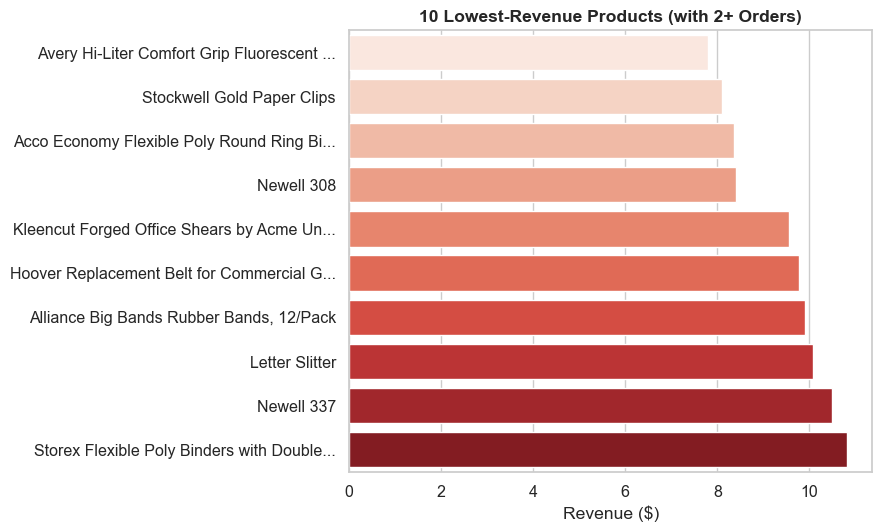

In [19]:
labels = [p[:40] + ("..." if len(p) > 40 else "") for p in worst_products.index]
plt.figure(figsize=(9, 5.5))
ax = sns.barplot(x=worst_products["Revenue"].values, y=labels, hue=worst_products.index, palette=sns.color_palette("Reds", 10), legend=False)
plt.title("10 Lowest-Revenue Products (with 2+ Orders)", fontweight="bold")
plt.xlabel("Revenue ($)")
plt.tight_layout()
plt.show()


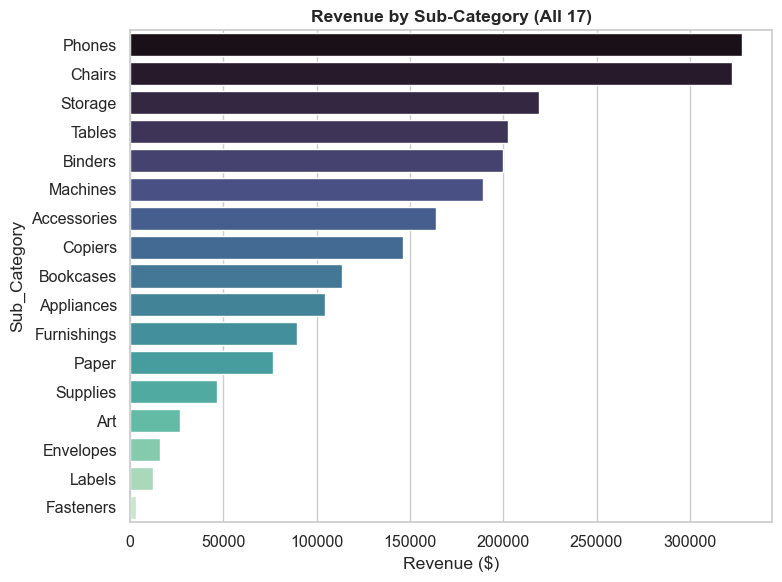

In [20]:
subcat = df.groupby("Sub_Category")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=subcat.values, y=subcat.index, hue=subcat.index, palette=sns.color_palette("mako", len(subcat)), legend=False)
plt.title("Revenue by Sub-Category (All 17)", fontweight="bold")
plt.xlabel("Revenue ($)")
plt.tight_layout()
plt.show()


## 7. Key Findings

1. **Revenue grew 30.6% in 2017 and 20.3% in 2018** after dipping 4.3% in 2016 — the business is on a strong upward trajectory in its most recent two years.
2. **The West and East regions generate 61% of total revenue** ($710K and $670K respectively), while the South region lags at just 17% ($389K) despite having a comparable number of orders.
3. **Technology has the highest revenue ($827K) despite having the fewest orders (1,519)** of the three categories — it carries a much higher average order value, while Office Supplies has 3,676 orders but the lowest total revenue, indicating many small-ticket purchases.
4. **Phones and Chairs are the top two sub-categories** (~$328K and ~$323K), while low-cost consumables (fasteners, labels, paper clips) cluster at the bottom of both the product and sub-category rankings.
5. **Revenue is highly seasonal**, peaking in November/December and dipping in the first quarter of each year — a pattern consistent with holiday-driven B2B/consumer purchasing.
6. **A single product — the Canon imageCLASS 2200 Advanced Copier — generated ~$61,600 from just 5 orders**, the highest revenue-per-order of any product, highlighting the outsized impact of high-ticket equipment sales.


## 8. Tactical Recommendations for Alfido Tech

1. **Double down on the West and East regions while running a targeted push in the South.** The South region under-indexes at only 17% of revenue with a similar order count to Central — investigate whether this is a coverage, pricing, or assortment gap and pilot region-specific promotions there.

2. **Bundle high-AOV Technology products with everyday Office Supplies.** Technology drives the most revenue per order; pairing big-ticket items (copiers, machines, phones) with complementary supplies (paper, binders, accessories) at checkout can lift the AOV of Office Supplies orders, which currently pulls down the overall average.

3. **Plan inventory and staffing around the Q4 seasonal peak.** Revenue consistently peaks in November/December — ensure stock levels, warehouse capacity, and shipping partners are scaled up ahead of this window, and consider extending seasonal promotions into the traditionally slower Q1.

4. **Review or discontinue chronic low-revenue SKUs.** Products like paper clips, rubber bands, and low-cost binders generate under $15 in total revenue despite multiple orders — evaluate whether these are loss-leaders worth keeping for basket-building or candidates for catalog pruning.

5. **Grow high-ticket equipment sales deliberately.** A handful of products (copiers, binding systems, videoconferencing units) generate outsized revenue from very few orders. A dedicated enterprise/B2B sales motion — outreach, financing options, or volume discounts — targeting these categories could meaningfully move total revenue with relatively few additional transactions.

**Data note:** this analysis is revenue-based only. To fully validate these recommendations — especially inventory pruning and bundling decisions — Alfido Tech should incorporate `Profit`, `Discount`, and `Quantity` data (available in fuller Superstore extracts) so that margin, not just top-line revenue, drives the final call.
